In [1]:
#!/usr/bin/env python3

# Menyesuaikan path agar dapat mengimpor modul dari direktori utama (induk)
# tanpa mengubah struktur direktori proyek
import sys
sys.path.append('..')

# Mengimpor file module untuk melakukan sync semua file
# pada direktori utama (induk)
import module

Proses deteksi apex dibutuhkan untuk mendapatkan rentang temporal yang akan digunakan pada proses deteksi ekspresi mikro yang memiliki fokus pada representasi gerakan

In [2]:
import os
from pathlib import Path


# Sumber data utama
BASE_DATASOURCE_PATH= os.path.join(Path.home().as_posix(), "datasets", "primary-converted")

# Sumber data kelas yang diambil pada 08/12/2025
# Terdapat dua tipe data (before dan after)
BASE_SUBJECT_GROUP_08122025_BEFORE_AFTER_PATH=os.path.join(BASE_DATASOURCE_PATH, "8-12-2025")

# Sumber data kelas yang diambil pada 09/12/2025
# Terdapat dua tipe data (before dan after)
BASE_SUBJECT_GROUP_09122025_BEFORE_AFTER_PATH=os.path.join(BASE_DATASOURCE_PATH, "9-12-2025")


# Verifikasi apakah path benar ada atau tidak
assert os.path.exists(BASE_DATASOURCE_PATH), f"Path tidak ditemukan: {BASE_DATASOURCE_PATH}"
assert os.path.exists(BASE_SUBJECT_GROUP_08122025_BEFORE_AFTER_PATH), f"Path tidak ditemukan: {BASE_SUBJECT_GROUP_08122025_BEFORE_AFTER_PATH}"
assert os.path.exists(BASE_SUBJECT_GROUP_09122025_BEFORE_AFTER_PATH), f"Path tidak ditemukan: {BASE_SUBJECT_GROUP_09122025_BEFORE_AFTER_PATH}"

print("Datasource path successfully set.")

Datasource path successfully set.


In [3]:
# Contoh video subjek untuk validasi teknik untuk memperoleh frame apex
validation_subject_video = os.path.join(BASE_SUBJECT_GROUP_08122025_BEFORE_AFTER_PATH, "aaisyah_nursalsabiil_ni_patriarti_1765168488512", "q1", "answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec.avi")

# Validasi keberadaan video subjek untuk validasi teknik
assert os.path.exists(validation_subject_video), f"Video tidak ditemukan: {validation_subject_video}"

Ekstraksi fase apex pada dataset primer yang sudah dikumpulkan

W0000 00:00:1771077302.548508   43861 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1771077302.555156   43865 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771077302.566957   43876 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


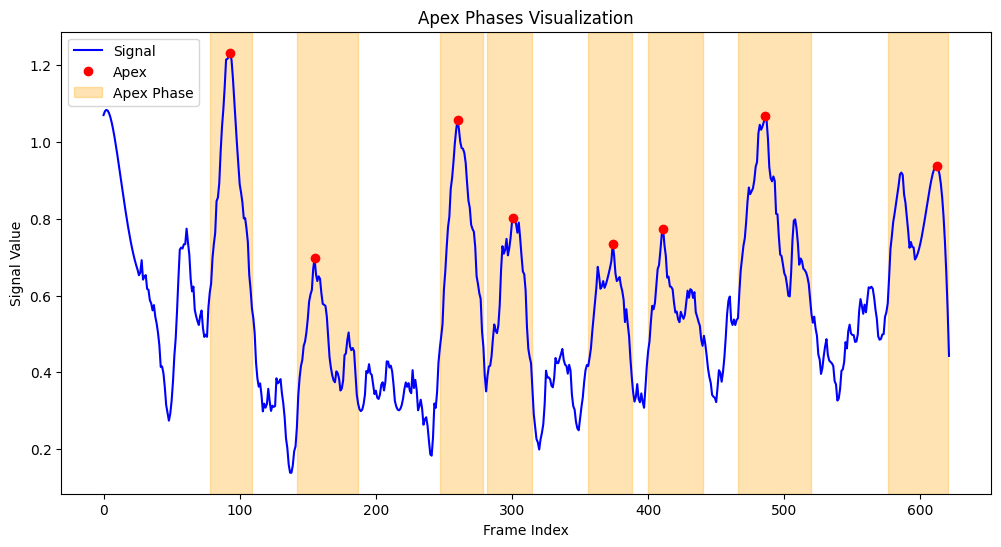

In [ ]:
# Ekstraksi magnitudo pada keseluruhan wajah

import numpy as np
from scipy.signal import savgol_filter
from src.video.modules import Video
from src.face.modules import FaceLandmark
from src.optical_flow.modules import TVL1
from src.apex.modules import ApexPhase, ApexSmoother, ApexPhaseVisualizer


face_landmark = FaceLandmark()

tvl1 = TVL1(fast_mode=True)

magnitudes = []

face_size = (240, 240)

def process(prev_frame: np.ndarray, curr_frame: np.ndarray, frame_index: int) -> np.ndarray:

    prev_landmarks = face_landmark.detect(prev_frame)
    next_landmarks = face_landmark.detect(curr_frame)

    prev_face = face_landmark.crop(image=prev_frame,
                                   landmarks=prev_landmarks,
                                   margin=0.05,
                                   output_size=face_size)

    next_face = face_landmark.crop(image=curr_frame,
                                   landmarks=next_landmarks,
                                   margin=0.05,
                                   output_size=face_size)

    flow = tvl1.compute(prev_face, next_face, download=False)

    flow = flow.download()

    dx = flow[..., 0]
    dy = flow[..., 1]

    magnitude = np.sqrt(dx**2 + dy**2)

    mean_magnitude = np.mean(magnitude)

    magnitudes.append(mean_magnitude)


apex_phase = ApexPhase(distance_threshold=11, prominence_threshold=0.3)

video = Video(video_path=validation_subject_video)
video.map(process)

window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_indices = apex_phase.find_apex(signal=smoothed_magnitudes)

phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apex_indices)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases(signal=smoothed_magnitudes,
                                  phases=phases,
                                  apex_indices=apex_indices)

W0000 00:00:1771078912.954390   48520 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1771078912.958923   48524 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771078912.969568   48536 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


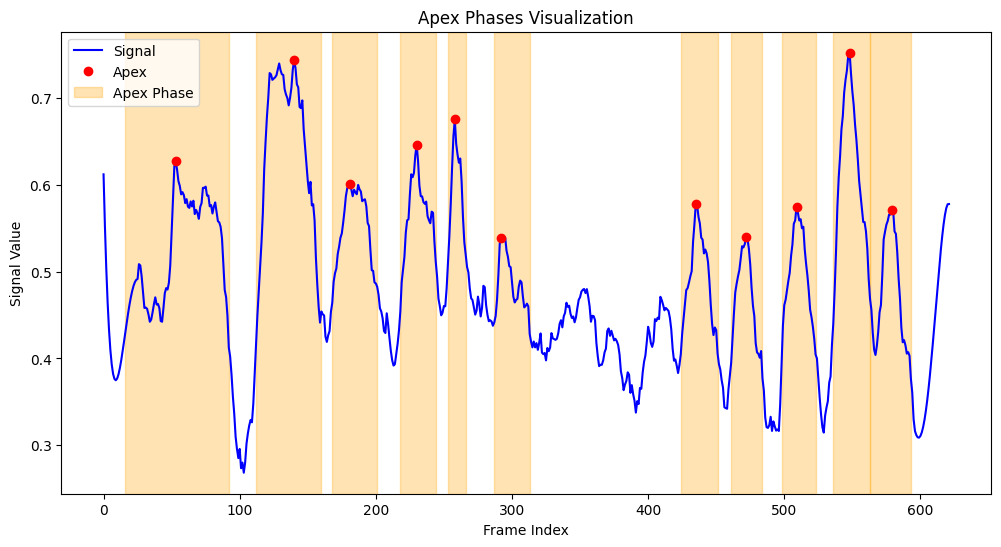

In [9]:
# Ekstraksi magnitudo pada keseluruhan wajah

import math
import numpy as np
from scipy.signal import savgol_filter
from src.video.modules import Video
from src.face.modules import FaceLandmark, FaceRoiPoints, FaceRoiSizes
from src.optical_flow.modules import TVL1
from src.apex.modules import ApexPhase, ApexSmoother, ApexPhaseVisualizer


face_landmark = FaceLandmark()

tvl1 = TVL1(fast_mode=True)

roi_defs = [
    frozenset(FaceRoiPoints.LEFT_EYE_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYE_POINTS),
    frozenset(FaceRoiPoints.LIPS_POINTS),
    frozenset(FaceRoiPoints.LEFT_EYEBROW_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYEBROW_POINTS),
]

tile_w, tile_h = (64, 64)
cols = 3
rows = math.ceil(len(roi_defs) / cols)
margin = 0.05

magnitudes = []

def process(prev_frame: np.ndarray, curr_frame: np.ndarray, frame_index: int) -> np.ndarray:

    prev_landmarks = face_landmark.detect(prev_frame)
    curr_landmarks = face_landmark.detect(curr_frame)

    canvas_prev = np.zeros((rows * tile_h, cols * tile_w, 3), dtype=np.uint8)
    canvas_next = np.zeros((rows * tile_h, cols * tile_w, 3), dtype=np.uint8)
    canvas_mask = np.zeros((rows * tile_h, cols * tile_w), dtype=np.uint8)

    for j, roi_points in enumerate(roi_defs):
        roi_prev, mask_prev = face_landmark.crop_roi(image=prev_frame,
                                                     landmark_result=prev_landmarks,
                                                     roi_points=roi_points,
                                                     margin=margin,
                                                     target_size=(tile_w, tile_h))
        
        roi_next, mask_next = face_landmark.crop_roi(image=curr_frame,
                                                        landmark_result=curr_landmarks,
                                                        roi_points=roi_points,
                                                        margin=margin,
                                                        target_size=(tile_w, tile_h))

        r, c = divmod(j, cols)
        y1, y2 = r * tile_h, (r + 1) * tile_h
        x1, x2 = c * tile_w, (c + 1) * tile_w

        canvas_prev[y1:y2, x1:x2] = roi_prev
        canvas_next[y1:y2, x1:x2] = roi_next
        canvas_mask[y1:y2, x1:x2] = ((mask_prev > 0) & (mask_next > 0)).astype(np.uint8)

    flow = tvl1.compute(canvas_prev, canvas_next, download=False)
    if hasattr(flow, "download"):
        flow = flow.download()

    magnitude = np.hypot(flow[..., 0], flow[..., 1])
    valid = canvas_mask > 0
    mean_magnitude = float(np.mean(magnitude[valid])) if np.any(valid) else float(np.mean(magnitude))
    magnitudes.append(mean_magnitude)


apex_phase = ApexPhase(distance_threshold=11, prominence_threshold=0.1)

video = Video(video_path=validation_subject_video)
video.map(process)

window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_indices = apex_phase.find_apex(signal=smoothed_magnitudes)

phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apex_indices)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases(signal=smoothed_magnitudes,
                                  phases=phases,
                                  apex_indices=apex_indices)

Membuat blueprint untuk centralisasi deteksi fase apex

In [10]:
import math
import numpy as np
from typing import List, Tuple, Literal
from scipy.signal import savgol_filter

from src.video.modules import Video
from src.face.modules import FaceLandmark, FaceRoiPoints
from src.optical_flow.modules import TVL1
from src.apex.modules import ApexPhase, ApexSmoother


ExtractionMode = Literal["roi", "fullface"]


class ApexPhaseSpotter:

    def __init__(self,
                 mode: ExtractionMode = "roi",
                 distance_threshold: int = 11,
                 prominence_threshold: float = 0.1,
                 tile_size: Tuple[int, int] = (64, 64),
                 face_size: Tuple[int, int] = (240, 240),
                 margin: float = 0.05):
        """
        Menginisialisasi blueprint untuk deteksi fase apex pada video ekspresi wajah mikro.
        Proses ekstraksi memiliki dua mode yaitu untuk keseluruhan area wajah dan juga fokus pada Region of Interest (RoI) tertentu seperti mata, bibir, dan alis.
        Deteksi fase apex dilakukan dengan menganalisis perubahan magnitudo optical flow menggunakan algoritma TV-L1, kemudian mengidentifikasi titik puncak (apex)
        dan fase berdasarkan kriteria jarak dan prominensi yang ditentukan.

        Args:
            mode (ExtractionMode): Mode ekstraksi yang digunakan, bisa "roi" untuk fokus pada RoI atau "fullface" untuk keseluruhan wajah.
            distance_threshold (int): Batas jarak minimum antara puncak yang terdeteksi untuk dianggap sebagai fase yang berbeda.
            prominence_threshold (float): Batas prominensi minimum untuk puncak yang terdeteksi agar dianggap valid.
            tile_size (Tuple[int, int]): Ukuran target untuk setiap RoI yang diekstraksi dalam mode "roi".
            face_size (Tuple[int, int]): Ukuran target untuk wajah yang diekstraksi dalam mode "fullface".
            margin (float): Margin tambahan yang diterapkan saat mengekstraksi RoI atau wajah untuk memastikan area yang cukup untuk analisis optical flow. 
                            Nilai ini dinyatakan sebagai persentase dari ukuran bounding box yang dihasilkan oleh deteksi landmark wajah.
        """

        self.mode = mode
        self.margin = margin

        self.landmarker = FaceLandmark()

        self.tvl1 = TVL1(fast_mode=True)

        self.apex_phase = ApexPhase(distance_threshold=distance_threshold,
                                    prominence_threshold=prominence_threshold)

        self.tile_w, self.tile_h = tile_size

        self.roi_defs = [frozenset(FaceRoiPoints.LEFT_EYE_POINTS),
                         frozenset(FaceRoiPoints.RIGHT_EYE_POINTS),
                         frozenset(FaceRoiPoints.LIPS_POINTS),
                         frozenset(FaceRoiPoints.LEFT_EYEBROW_POINTS),
                         frozenset(FaceRoiPoints.RIGHT_EYEBROW_POINTS)]

        self.cols = 3
        self.rows = math.ceil(len(self.roi_defs) / self.cols)

        self.face_size = face_size

        self.magnitudes: List[float] = []


    def process(self, video_path: str) -> Tuple[List[int], List[int]]:

        self.magnitudes.clear()

        video = Video(video_path=video_path)

        if self.mode == "roi":
            video.map(self.__process_roi)
        elif self.mode == "fullface":
            video.map(self.__process_fullface)
        else:
            raise ValueError(f"Unsupported mode: {self.mode}")

        return self.__find_apex_phase(self.magnitudes)


    def __process_roi(self,
                      prev_frame: np.ndarray,
                      curr_frame: np.ndarray,
                      frame_index: int) -> None:

        prev_landmarks = self.landmarker.detect(prev_frame)
        curr_landmarks = self.landmarker.detect(curr_frame)

        canvas_mask = np.zeros((self.rows * self.tile_h, self.cols * self.tile_w),dtype=np.uint8)
        canvas_prev = np.zeros((self.rows * self.tile_h, self.cols * self.tile_w, 3), dtype=np.uint8)
        canvas_next = np.zeros_like(canvas_prev)

        for j, roi_points in enumerate(self.roi_defs):

            roi_prev, mask_prev = self.landmarker.crop_roi(image=prev_frame,
                                                           landmark_result=prev_landmarks,
                                                           roi_points=roi_points,
                                                           margin=self.margin,
                                                           target_size=(self.tile_w, self.tile_h))

            roi_next, mask_next = self.landmarker.crop_roi(image=curr_frame,
                                                           landmark_result=curr_landmarks,
                                                           roi_points=roi_points,
                                                           margin=self.margin,
                                                           target_size=(self.tile_w, self.tile_h))

            r, c = divmod(j, self.cols)
            y1, y2 = r * self.tile_h, (r + 1) * self.tile_h
            x1, x2 = c * self.tile_w, (c + 1) * self.tile_w

            canvas_prev[y1:y2, x1:x2] = roi_prev
            canvas_next[y1:y2, x1:x2] = roi_next

            canvas_mask[y1:y2, x1:x2] = ((mask_prev > 0) & (mask_next > 0)).astype(np.uint8)

        flow = self.tvl1.compute(canvas_prev, canvas_next, download=False)

        if hasattr(flow, "download"): flow = flow.download()

        magnitude = np.hypot(flow[..., 0], flow[..., 1])

        valid = canvas_mask > 0
        mean_magnitude = (float(np.mean(magnitude[valid])) if np.any(valid) else float(np.mean(magnitude)))

        self.magnitudes.append(mean_magnitude)


    def __process_fullface(self,
                           prev_frame: np.ndarray,
                           curr_frame: np.ndarray,
                           frame_index: int) -> None:

        prev_landmarks = self.landmarker.detect(prev_frame)
        curr_landmarks = self.landmarker.detect(curr_frame)

        prev_face = self.landmarker.crop(image=prev_frame,
                                         landmarks=prev_landmarks,
                                         margin=self.margin,
                                         output_size=self.face_size)

        curr_face = self.landmarker.crop(image=curr_frame,
                                         landmarks=curr_landmarks,
                                         margin=self.margin,
                                         output_size=self.face_size)

        flow = self.tvl1.compute(prev_face, curr_face, download=False)

        if hasattr(flow, "download"): flow = flow.download()

        magnitude = np.hypot(flow[..., 0], flow[..., 1])

        mean_magnitude = float(np.mean(magnitude))

        self.magnitudes.append(mean_magnitude)


    def __find_apex_phase(self,
                          magnitudes: List[float]) -> Tuple[List[int], List[int]]:

        window_length = ApexSmoother.calculate_window_length(len(magnitudes))
        polyorder = ApexSmoother.calculate_polyorder(window_length)

        smoothed = savgol_filter(magnitudes, window_length, polyorder)

        apex_indices = self.apex_phase.find_apex(signal=smoothed)

        phases = self.apex_phase.find_phase(signal=smoothed, apex_indices=apex_indices)

        return apex_indices, phases


In [ ]:
spotter = ApexPhaseSpotter(distance_threshold=11, prominence_threshold=0.2, mode="roi")

apex_phase, phases = spotter.process(video_path=validation_subject_video)

print(apex_phase, phases)

W0000 00:00:1771079560.722591   49433 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1771079560.727080   49436 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771079560.738678   49450 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


[53, 140, 258, 435, 509, 548] {53: {'start': 16, 'end': 92}, 140: {'start': 112, 'end': 163}, 258: {'start': 252, 'end': 269}, 435: {'start': 424, 'end': 451}, 509: {'start': 498, 'end': 523}, 548: {'start': 536, 'end': 564}}
